In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df[['v1', 'v2']]

In [5]:
df.columns = ['label', 'message']

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 2)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 403


In [13]:
df = df.drop_duplicates()

In [14]:
print("New Shape:", df.shape)

New Shape: (5169, 2)


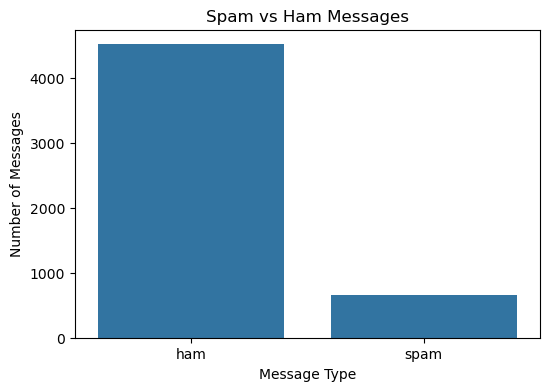

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [16]:
def preprocess_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    # Remove leading and trailing spaces
    text = text.strip()
    
    return text

In [17]:
df['clean_message'] = df['message'].apply(preprocess_text)

In [18]:
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


In [19]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

In [20]:
df[['label', 'label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [21]:
X = df['clean_message']
y = df['label_num']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [24]:
tfidf = TfidfVectorizer(
    stop_words='english'
)

In [25]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [26]:
X_test_tfidf = tfidf.transform(X_test)

In [27]:
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4135, 7108)
Testing TF-IDF Shape: (1034, 7108)


In [28]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29874 stored elements and shape (4135, 7108)>

In [29]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6417 stored elements and shape (1034, 7108)>

In [30]:
model = MultinomialNB()

In [31]:
model.fit(
    X_train_tfidf,
    y_train
)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [32]:
y_pred = model.predict(X_test_tfidf)

In [33]:
print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9622823984526112
Accuracy Percentage: 96.22823984526111 %


In [35]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.9893617021276596


In [36]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.7099236641221374


In [37]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.8266666666666667


In [38]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.71      0.83       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [39]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[902   1]
 [ 38  93]]


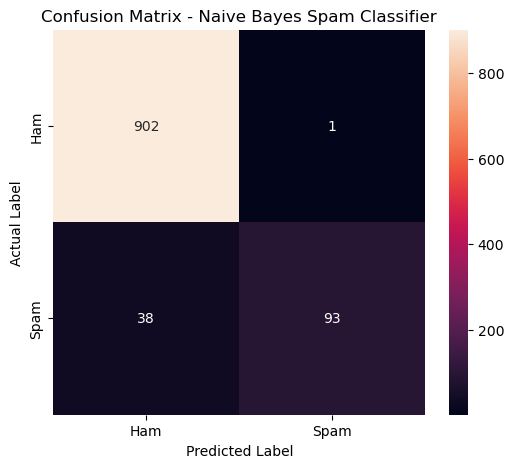

In [40]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Naive Bayes Spam Classifier')

plt.show()

In [41]:
test_messages = [
    "Hey bro, are you coming to college tomorrow?",
    "Congratulations! You won a free iPhone. Click now!",
    "Can you call me when you reach home?",
    "URGENT! You have won 10000 dollars. Claim your prize now!",
    "What time is the class today?"
]

In [42]:
clean_test_messages = [
    preprocess_text(message)
    for message in test_messages
]

In [43]:
test_tfidf = tfidf.transform(
    clean_test_messages
)

In [44]:
predictions = model.predict(
    test_tfidf
)

In [45]:
for message, prediction in zip(
    test_messages,
    predictions
):
    
    result = "SPAM" if prediction == 1 else "HAM"
    
    print("Message:", message)
    print("Prediction:", result)
    print("-" * 60)

Message: Hey bro, are you coming to college tomorrow?
Prediction: HAM
------------------------------------------------------------
Message: Congratulations! You won a free iPhone. Click now!
Prediction: SPAM
------------------------------------------------------------
Message: Can you call me when you reach home?
Prediction: HAM
------------------------------------------------------------
Message: URGENT! You have won 10000 dollars. Claim your prize now!
Prediction: SPAM
------------------------------------------------------------
Message: What time is the class today?
Prediction: HAM
------------------------------------------------------------


In [46]:
probabilities = model.predict_proba(
    test_tfidf
)

In [47]:
for message, prediction, probability in zip(
    test_messages,
    predictions,
    probabilities
):
    
    result = "SPAM" if prediction == 1 else "HAM"
    
    print("Message:", message)
    print("Prediction:", result)
    print(
        "Spam Probability:",
        round(probability[1] * 100, 2),
        "%"
    )
    print("-" * 60)

Message: Hey bro, are you coming to college tomorrow?
Prediction: HAM
Spam Probability: 1.16 %
------------------------------------------------------------
Message: Congratulations! You won a free iPhone. Click now!
Prediction: SPAM
Spam Probability: 74.2 %
------------------------------------------------------------
Message: Can you call me when you reach home?
Prediction: HAM
Spam Probability: 1.33 %
------------------------------------------------------------
Message: URGENT! You have won 10000 dollars. Claim your prize now!
Prediction: SPAM
Spam Probability: 96.17 %
------------------------------------------------------------
Message: What time is the class today?
Prediction: HAM
Spam Probability: 0.55 %
------------------------------------------------------------


In [48]:
import joblib

In [49]:
joblib.dump(
    model,
    "models/spam_model.pkl"
)

['models/spam_model.pkl']

In [50]:
joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

['models/tfidf_vectorizer.pkl']